## **Configure Kaggle & Download Dataset**

In [1]:
from google.colab import files
files.upload()  # This will prompt you to upload kaggle.json

import os
import zipfile

# Move kaggle.json to the right place
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

# Install Kaggle CLI
!pip install -q kaggle

# Download and unzip dataset
!kaggle datasets download -d dhoogla/unswnb15

with zipfile.ZipFile("unswnb15.zip", 'r') as zip_ref:
    zip_ref.extractall("unsw_nb15")


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/dhoogla/unswnb15
License(s): CC-BY-NC-SA-4.0
  0% 0.00/11.7M [00:00<?, ?B/s]
100% 11.7M/11.7M [00:00<00:00, 948MB/s]


# **Read & Concatenate Train/Test Data**

In [2]:
import pandas as pd

train_df = pd.read_parquet("/content/unsw_nb15/UNSW_NB15_training-set.parquet")
test_df = pd.read_parquet("/content/unsw_nb15/UNSW_NB15_testing-set.parquet")
df = pd.concat([train_df, test_df], ignore_index=True)
df.head()


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                257673 non-null  float32 
 1   proto              257673 non-null  object  
 2   service            257673 non-null  category
 3   state              257673 non-null  object  
 4   spkts              257673 non-null  int16   
 5   dpkts              257673 non-null  int16   
 6   sbytes             257673 non-null  int32   
 7   dbytes             257673 non-null  int32   
 8   rate               257673 non-null  float32 
 9   sload              257673 non-null  float32 
 10  dload              257673 non-null  float32 
 11  sloss              257673 non-null  int16   
 12  dloss              257673 non-null  int16   
 13  sinpkt             257673 non-null  float32 
 14  dinpkt             257673 non-null  float32 
 15  sjit               257673 non-null

 # **Preprocess the Dataset**

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Make a copy
df_clean = df.copy()



# Encode object and categorical columns
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# Separate features and target
X = df_clean.drop(columns=['label'])
y = df_clean['label']


# **Exploratry data Analysis**

## **Visualize Label Distribution**

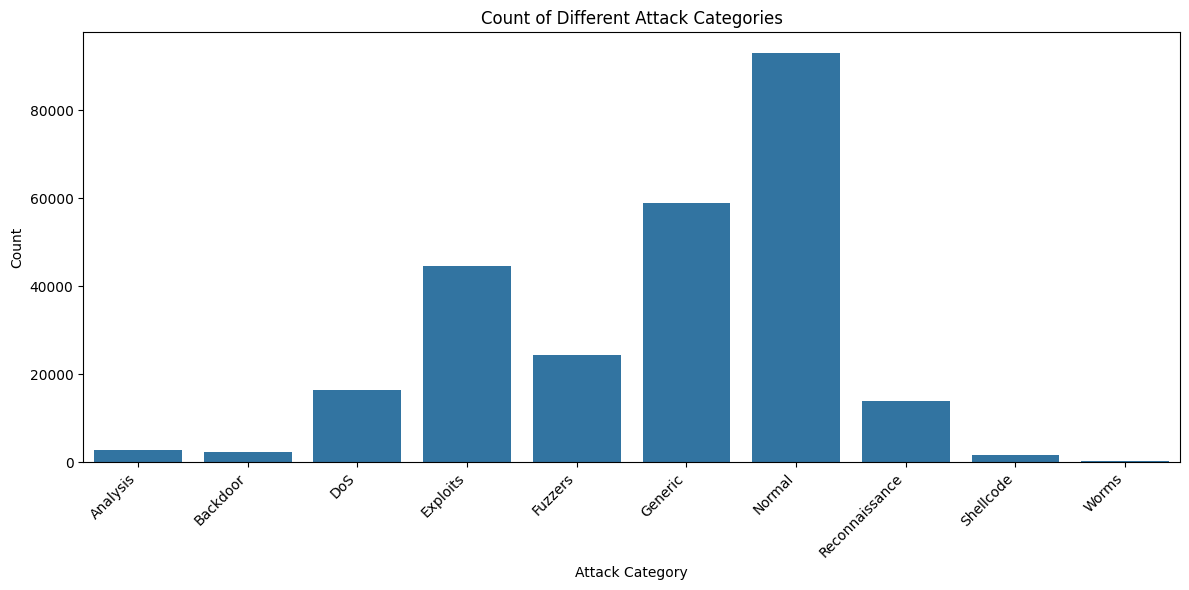

In [5]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='attack_cat')
plt.title('Count of Different Attack Categories')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


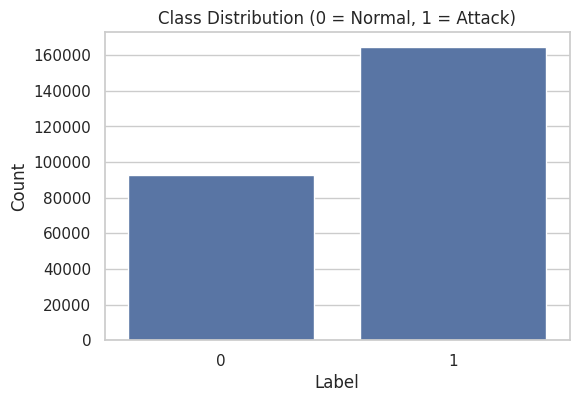

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Class Distribution (0 = Normal, 1 = Attack)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


# **Count plot to show protocol by attack Category**

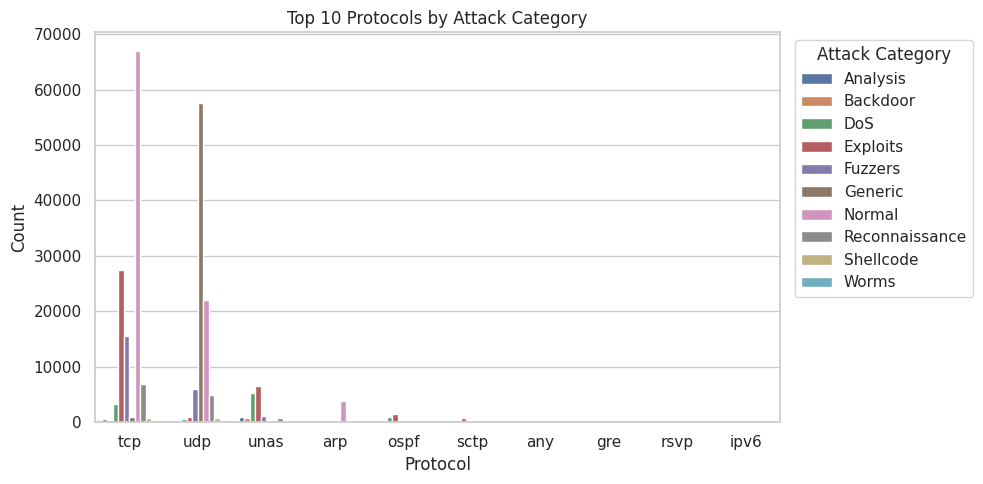

In [7]:

# Identify top 10 most common protocols
top_protos = df['proto'].value_counts().nlargest(10).index

# Filter dataset to top protocols only
filtered_df = df[df['proto'].isin(top_protos)]

# Plot
plt.figure(figsize=(10, 5))
sns.countplot(data=filtered_df, x='proto', hue='attack_cat', order=top_protos)
plt.title("Top 10 Protocols by Attack Category")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Attack Category')
plt.tight_layout()
plt.show()

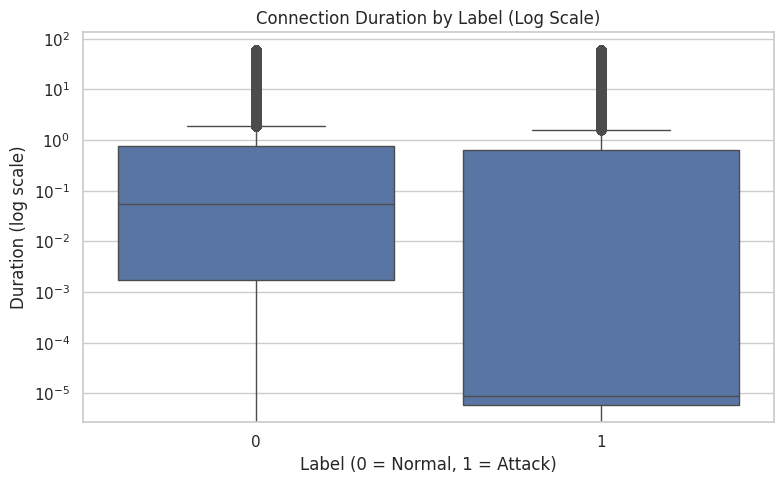

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='dur')
plt.yscale("log")
plt.title("Connection Duration by Label (Log Scale)")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Duration (log scale)")
plt.tight_layout()
plt.show()

# **Split the Data Set**

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)


# **Model Development**

## **Machine Learning Model**


--- Training and Evaluating Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Time: 73.5195 seconds
Testing Time: 0.0209 seconds
Accuracy: 0.8012
Precision: 0.7866
Recall: 0.9453
F1-score: 0.8587

 Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.55      0.67     18622
           1       0.79      0.95      0.86     32913

    accuracy                           0.80     51535
   macro avg       0.82      0.75      0.76     51535
weighted avg       0.81      0.80      0.79     51535



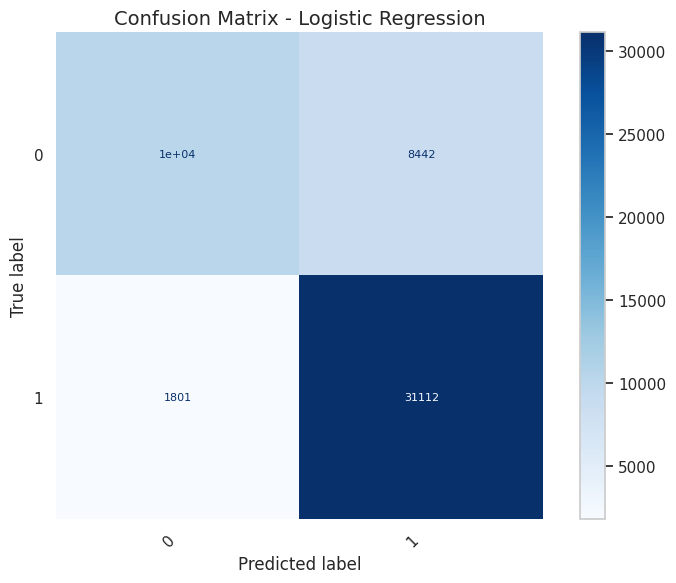

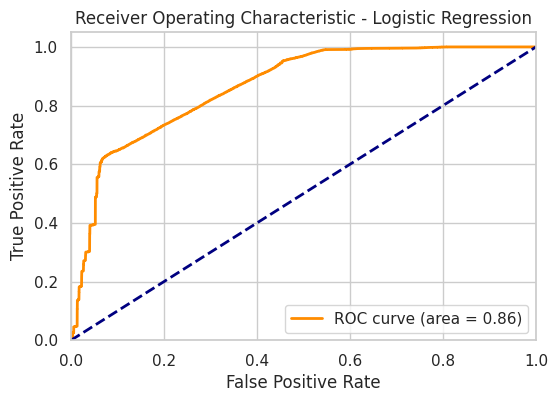


--- Training and Evaluating K-Nearest Neighbors ---
Training Time: 0.0787 seconds
Testing Time: 82.5817 seconds
Accuracy: 0.8572
Precision: 0.8722
Recall: 0.9098
F1-score: 0.8906

 Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.76      0.79     18622
           1       0.87      0.91      0.89     32913

    accuracy                           0.86     51535
   macro avg       0.85      0.84      0.84     51535
weighted avg       0.86      0.86      0.86     51535



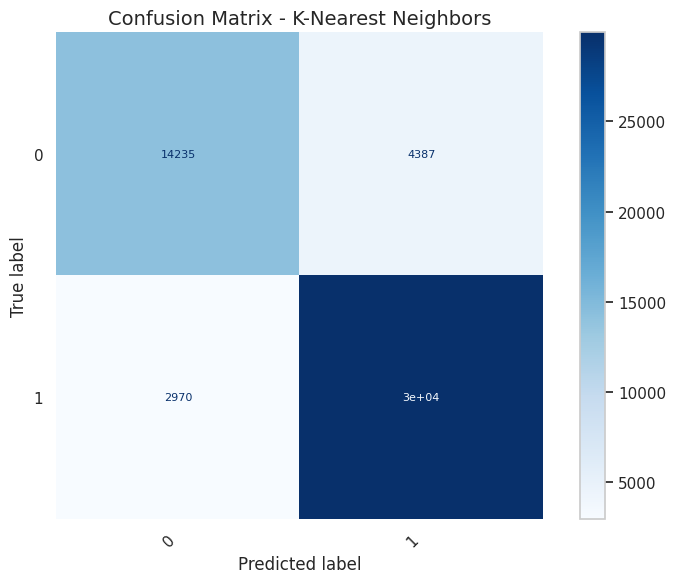

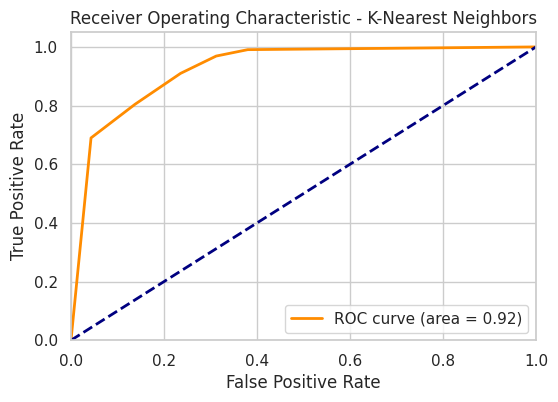


--- Training and Evaluating Gaussian Naive Bayes ---
Training Time: 0.2086 seconds
Testing Time: 0.0326 seconds
Accuracy: 0.7634
Precision: 0.8025
Recall: 0.8350
F1-score: 0.8185

 Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.64      0.66     18622
           1       0.80      0.84      0.82     32913

    accuracy                           0.76     51535
   macro avg       0.74      0.74      0.74     51535
weighted avg       0.76      0.76      0.76     51535



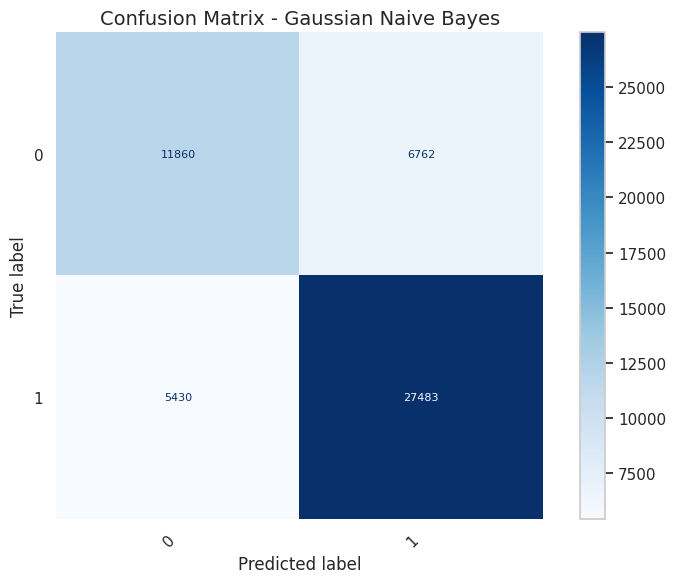

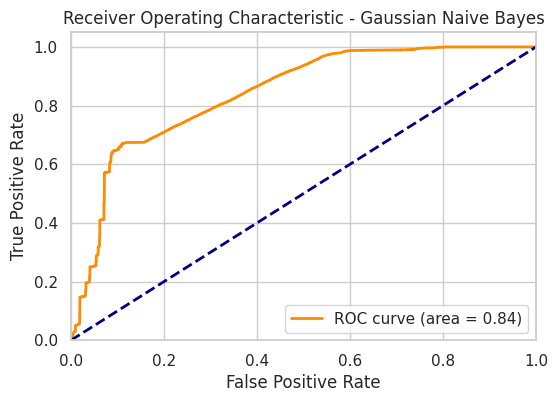


--- Training and Evaluating Neural Network ---
Training Time: 76.2701 seconds
Testing Time: 0.1156 seconds
Accuracy: 0.8222
Precision: 0.7862
Recall: 0.9912
F1-score: 0.8768

 Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.52      0.68     18622
           1       0.79      0.99      0.88     32913

    accuracy                           0.82     51535
   macro avg       0.88      0.76      0.78     51535
weighted avg       0.85      0.82      0.81     51535



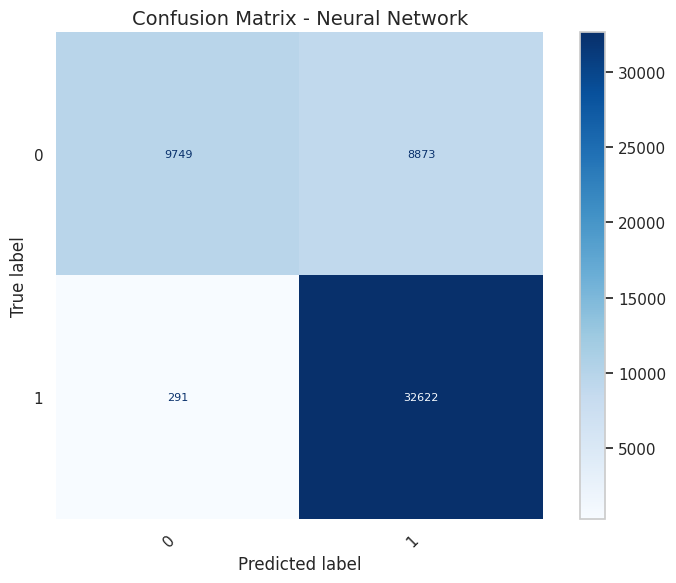

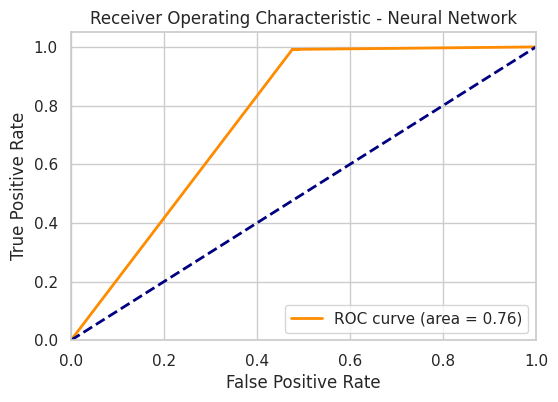


--- Model Performance Summary ---


,Training Time (s),Testing Time (s),Accuracy,Precision,Recall,F1-score,ROC AUC
Logistic Regression,73.519472,0.020948,0.801242,0.786570,0.945280,0.858653,0.864910
K-Nearest Neighbors,0.078699,82.581708,0.857243,0.872211,0.909762,0.890591,0.924951
Gaussian Naive Bayes,0.208591,0.032585,0.763423,0.802541,0.835020,0.818458,0.842288
Neural Network,76.270113,0.115649,0.822179,0.786167,0.991159,0.876841,0.757712


In [10]:

import pandas as pd
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Dictionary to store models and their names
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=17),

    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=17)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training and Evaluating {name} ---")

    # Training time
    start_train_time = time.time()
    model.fit(X_train, y_train)
    end_train_time = time.time()
    train_time = end_train_time - start_train_time

    # Testing time and prediction
    start_test_time = time.time()
    y_pred = model.predict(X_test)
    end_test_time = time.time()
    test_time = end_test_time - start_test_time

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        "Training Time (s)": train_time,
        "Testing Time (s)": test_time,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    print(f"Training Time: {train_time:.4f} seconds")
    print(f"Testing Time: {test_time:.4f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Classification Report
    print("\n Classification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))


    # Clean and readable Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))  # Bigger size for clarity
    disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap='Blues',
        ax=ax,
        colorbar=True
    )

    # Remove background lines & borders
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Adjust axis labels
    disp.ax_.set_xlabel('Predicted label', fontsize=12)
    disp.ax_.set_ylabel('True label', fontsize=12)

    # Reduce font size for cell numbers
    for text in disp.ax_.texts:
        text.set_fontsize(8)

    # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Title & layout
    plt.title(f"Confusion Matrix - {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # ROC Curve and AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - {name}')
        plt.legend(loc="lower right")
        plt.show()
        results[name]["ROC AUC"] = roc_auc
    else:
        print("ROC curve not available for this model.")

# Display a summary of results
print("\n--- Model Performance Summary ---")
results_df = pd.DataFrame(results).T
results_df

## **Deep learning Modle**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,049 (148.63 KB)

 Trainable params: 38,049 (148.63 KB)

...

5154/5154 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - accuracy: 0.9999 - f1_score: 0.8013 - loss: 6.1591e-04 - precision: 0.9999 - recall: 0.9999 - val_accuracy: 0.9995 - val_f1_score: 0.7773 - val_loss: 8.4334e-04 - val_precision: 0.9992 - val_recall: 1.0000
Epoch 29/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.9999 - f1_score: 0.8048 - loss: 9.1820e-04 - precision: 0.9998 - recall: 1.0000 - val_accuracy: 0.9998 - val_f1_score: 0.7773 - val_loss: 9.9569e-04 - val_precision: 0.9997 - val_recall: 1.0000
Epoch 30/50
5150/5154 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9997 - f1_score: 0.8060 - loss: 0.0011 - precision: 0.9997 - recall: 0.9998

5154/5154 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9997 - f1_score: 0.8060 - loss: 0.0011 - precision: 0.9997 - recall: 0.9998 - val_accuracy: 1.0000 - val_f1_score: 0.7797 - val_loss: 6.9589e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 31/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9999 - f1_score: 0.7995 - loss: 6.7956e-04 - precision: 0.9999 - recall: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.7773 - val_loss: 7.2183e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 32/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9998 - f1_score: 0.7877 - loss: 0.0010 - precision: 0.9998 - recall: 1.0000 - val_accuracy: 0.9998 - val_f1_score: 0.7773 - val_loss: 0.0022 - val_precision: 0.9996 - val_recall: 1.0000
Epoch 33/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9998 - f1_score: 0.7863 - loss: 7.3834e-04 - precision: 0.9998 - recall: 0.9999

5154/5154 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.9998 - f1_score: 0.7863 - loss: 7.3831e-04 - precision: 0.9998 - recall: 0.9999 - val_accuracy: 1.0000 - val_f1_score: 0.7805 - val_loss: 5.2537e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 34/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9998 - f1_score: 0.7888 - loss: 0.0011 - precision: 0.9997 - recall: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.7785 - val_loss: 5.7505e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 35/50
5152/5154 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9999 - f1_score: 0.7948 - loss: 7.4671e-04 - precision: 0.9998 - recall: 1.0000

5154/5154 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9999 - f1_score: 0.7948 - loss: 7.4671e-04 - precision: 0.9998 - recall: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.7792 - val_loss: 4.7595e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 36/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.9999 - f1_score: 0.7920 - loss: 3.9923e-04 - precision: 0.9999 - recall: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.7773 - val_loss: 6.0112e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 37/50
5148/5154 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9999 - f1_score: 0.7854 - loss: 4.7091e-04 - precision: 0.9999 - recall: 1.0000

5154/5154 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9999 - f1_score: 0.7854 - loss: 4.7102e-04 - precision: 0.9999 - recall: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.7773 - val_loss: 4.2357e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 38/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9999 - f1_score: 0.7865 - loss: 6.3604e-04 - precision: 0.9999 - recall: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.7773 - val_loss: 5.2132e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 39/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - accuracy: 0.9999 - f1_score: 0.7858 - loss: 5.2666e-04 - precision: 0.9999 - recall: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.7773 - val_loss: 4.5926e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 40/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - accuracy: 0.9998 - f1_score: 0.7809 - loss: 9.2485e-04 - precision: 0.9997 - recall: 1.0000 - val_accuracy: 0.9998 - val_f1_score: 0.7773 - val_loss: 0.0012 - val

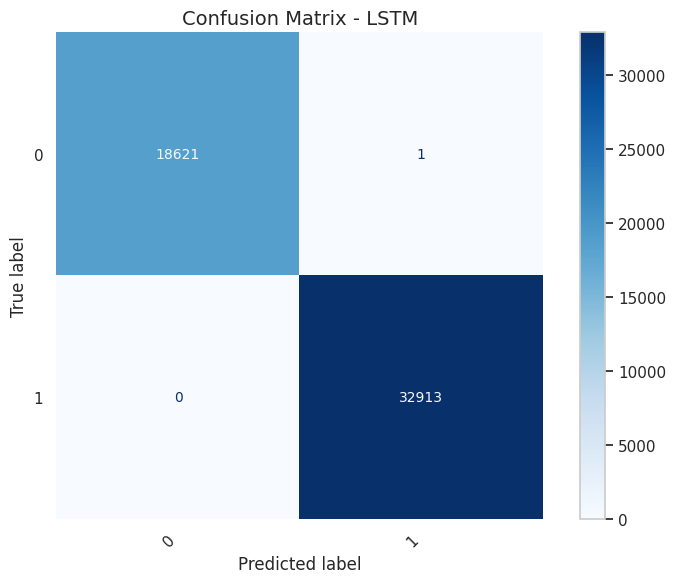


--- Plotting LSTM Training History ---


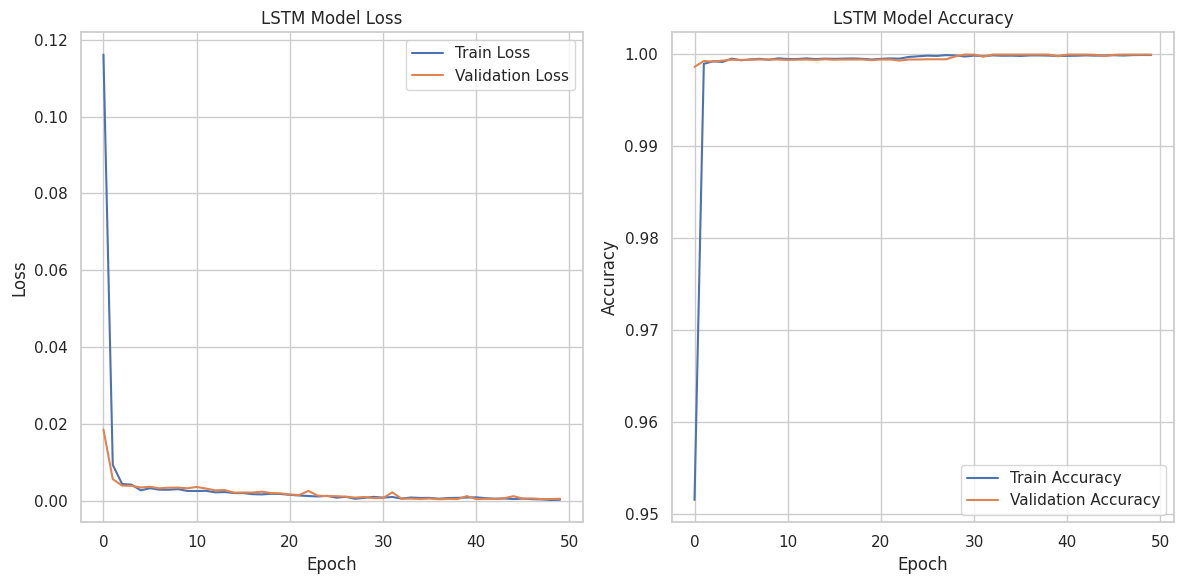

1611/1611 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


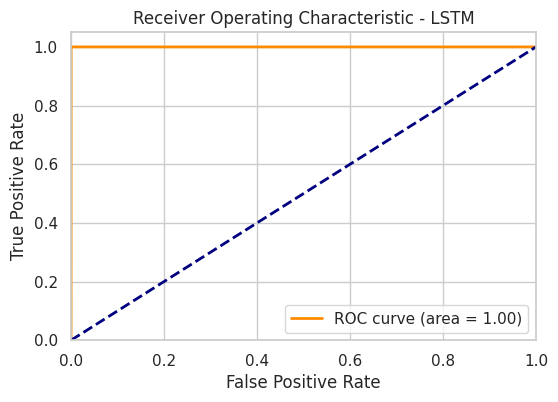


--- Updated Model Performance Summary ---


,Training Time (s),Testing Time (s),Accuracy,Precision,Recall,F1-score,ROC AUC
Logistic Regression,73.519472,0.020948,0.801242,0.786570,0.945280,0.858653,0.864910
K-Nearest Neighbors,0.078699,82.581708,0.857243,0.872211,0.909762,0.890591,0.924951
Gaussian Naive Bayes,0.208591,0.032585,0.763423,0.802541,0.835020,0.818458,0.842288
Neural Network,76.270113,0.115649,0.822179,0.786167,0.991159,0.876841,0.757712
LSTM,1758.697764,5.192787,0.999981,0.999970,1.000000,0.779504,0.999971


In [11]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.metrics import Accuracy, Precision, Recall, F1Score
import tensorflow as tf


# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for LSTM (samples, timesteps, features)
# For this dataset, each sample is a single timestep
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Build the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=32, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=1, activation='sigmoid')) # Binary classification

# Compile the model
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), F1Score()])

lstm_model.summary()

# Define callbacks for fine-tuning and saving the best model
# [removed early stopping]
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_lstm_model.h5', save_best_only=True, monitor='val_loss')

# Train the model
print("\n--- Training the LSTM Model ---")
start_lstm_train_time = time.time()
history = lstm_model.fit(
    X_train_reshaped, y_train,
    epochs=50,
    validation_split=0.2, # Use part of training data for validation during training
    callbacks=[model_checkpoint]
)
end_lstm_train_time = time.time()
lstm_train_time = end_lstm_train_time - start_lstm_train_time
print(f"LSTM Training Time: {lstm_train_time:.4f} seconds")

# Evaluate the model on the test set
print("\n--- Evaluating the LSTM Model ---")
start_lstm_test_time = time.time()
loss, accuracy, precision, recall, f1 = lstm_model.evaluate(X_test_reshaped, y_test, verbose=0)
end_lstm_test_time = time.time()
lstm_test_time = end_lstm_test_time - start_lstm_test_time
print(f"LSTM Testing Time: {lstm_test_time:.4f} seconds")

print(f"LSTM Test Loss: {loss:.4f}")
print(f"LSTM Test Accuracy: {accuracy:.4f}")
print(f"LSTM Test Precision: {precision:.4f}")
print(f"LSTM Test Recall: {recall:.4f}")
print(f"LSTM Test F1 Score: {f1:.4f}")

# Classification Report (needs thresholding for binary prediction)
y_pred_prob = lstm_model.predict(X_test_reshaped)
y_pred_lstm = (y_pred_prob > 0.5).astype("int32") # Threshold at 0.5

print("\n LSTM Classification Report:\n")
print(classification_report(y_test, y_pred_lstm, zero_division=0))


# Confusion Matrix for LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

fig, ax = plt.subplots(figsize=(8, 6))  # Larger size for clarity
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=[0, 1])

# Plot with clean style
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.grid(False)  # Remove background grid lines
for spine in ax.spines.values():
    spine.set_visible(False)  # Remove borders

# Label settings
disp.ax_.set_xlabel('Predicted label', fontsize=12)
disp.ax_.set_ylabel('True label', fontsize=12)

# Reduce font size of numbers inside cells
for text in disp.ax_.texts:
    text.set_fontsize(10)

# Rotate x-axis labels if needed
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Title and layout
plt.title("Confusion Matrix - LSTM", fontsize=14)
plt.tight_layout()
plt.show()
# Plot training history
print("\n--- Plotting LSTM Training History ---")
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# ROC Curve and AUC for LSTM
y_proba_lstm = lstm_model.predict(X_test_reshaped).ravel()
fpr_lstm, tpr_lstm, thresholds_lstm = roc_curve(y_test, y_proba_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lstm, tpr_lstm, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_lstm)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - LSTM')
plt.legend(loc="lower right")
plt.show()

# Add LSTM results to the summary
results['LSTM'] = {
    "Training Time (s)": lstm_train_time,
    "Testing Time (s)": lstm_test_time,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC AUC": roc_auc_lstm
}

# Display updated summary of results
print("\n--- Updated Model Performance Summary ---")
results_df_updated = pd.DataFrame(results).T
results_df_updated


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 64)          │        19,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,833 (112.63 KB)

 Trainable params: 28,833 (112.63 KB)

...

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 1.0000 - f1_score: 0.9224 - loss: 6.6483e-06 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.9654 - val_loss: 2.2180e-07 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 32/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 1.0000 - f1_score: 0.9089 - loss: 1.5703e-05 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.9455 - val_loss: 6.3090e-05 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 33/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9998 - f1_score: 0.9261 - loss: 6.4600e-04 - precision_1: 0.9998 - recall_1: 0.9999 - val_accuracy: 1.0000 - val_f1_score: 0.9842 - val_loss: 4.2413e-07 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 34/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9999 - f1_score: 0.9219 - loss: 3.2464e-04 - precision_1: 0.9999 - recall_1: 0.9999 - val_accuracy: 1.0000 - val_f1_score: 0.9

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 1.0000 - f1_score: 0.9060 - loss: 2.3710e-05 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.9320 - val_loss: 1.4564e-07 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 36/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9999 - f1_score: 0.9090 - loss: 3.3529e-04 - precision_1: 0.9999 - recall_1: 0.9999 - val_accuracy: 1.0000 - val_f1_score: 0.9862 - val_loss: 1.9572e-07 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 37/50
2568/2577 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - f1_score: 0.9139 - loss: 9.2897e-06 - precision_1: 1.0000 - recall_1: 1.0000

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 1.0000 - f1_score: 0.9139 - loss: 9.2790e-06 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.9683 - val_loss: 1.3794e-07 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 38/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9999 - f1_score: 0.9145 - loss: 2.4250e-04 - precision_1: 0.9999 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.9765 - val_loss: 6.0766e-05 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 39/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 1.0000 - f1_score: 0.9149 - loss: 6.7891e-06 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.9847 - val_loss: 9.3875e-06 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 40/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9999 - f1_score: 0.9303 - loss: 2.5259e-04 - precision_1: 0.9999 - recall_1: 0.9999 - val_accuracy: 1.0000 - val_f1_score: 0.9

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 1.0000 - f1_score: 0.9568 - loss: 4.6691e-06 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.9947 - val_loss: 1.1878e-07 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 45/50
2569/2577 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - f1_score: 0.9513 - loss: 3.1106e-06 - precision_1: 1.0000 - recall_1: 1.0000

2577/2577 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 1.0000 - f1_score: 0.9512 - loss: 3.1113e-06 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.9870 - val_loss: 7.9254e-08 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 46/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9999 - f1_score: 0.9530 - loss: 5.0017e-04 - precision_1: 0.9999 - recall_1: 0.9999 - val_accuracy: 1.0000 - val_f1_score: 0.9983 - val_loss: 3.1197e-04 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 47/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 1.0000 - f1_score: 0.9676 - loss: 1.8622e-04 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.9871 - val_loss: 9.3109e-07 - val_precision_1: 1.0000 - val_recall_1: 1.0000
Epoch 48/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 1.0000 - f1_score: 0.9566 - loss: 5.1455e-06 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 1.0000 - val_f1_score: 0.9

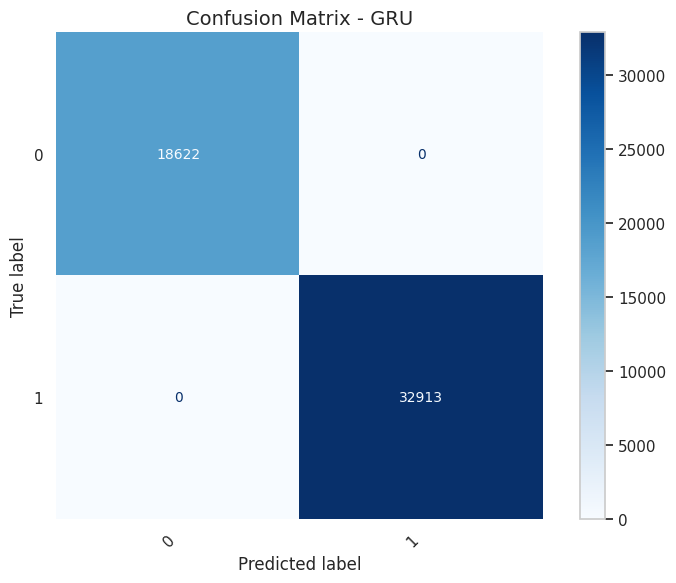


--- Plotting GRU Training History ---


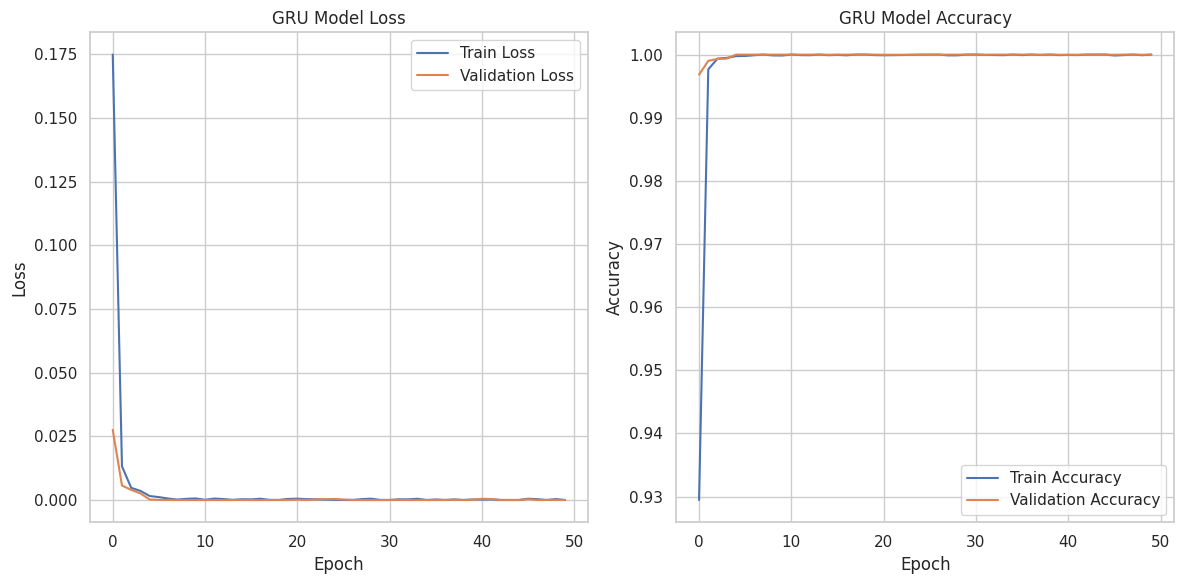

1611/1611 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


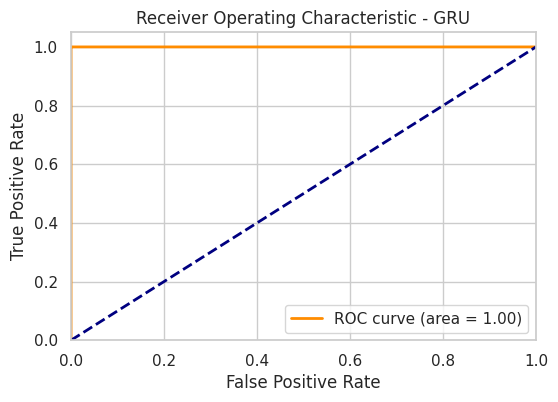


--- Updated Model Performance Summary ---


,Training Time (s),Testing Time (s),Accuracy,Precision,Recall,F1-score,ROC AUC
Logistic Regression,73.519472,0.020948,0.801242,0.786570,0.945280,0.858653,0.864910
K-Nearest Neighbors,0.078699,82.581708,0.857243,0.872211,0.909762,0.890591,0.924951
Gaussian Naive Bayes,0.208591,0.032585,0.763423,0.802541,0.835020,0.818458,0.842288
Neural Network,76.270113,0.115649,0.822179,0.786167,0.991159,0.876841,0.757712
LSTM,1758.697764,5.192787,0.999981,0.999970,1.000000,0.779504,0.999971
GRU,854.952759,3.282160,1.000000,1.000000,1.000000,0.990043,1.000000


In [12]:


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, F1Score

# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for GRU (samples, timesteps, features)
# For this dataset, each sample is a single timestep
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# Build the GRU model
gru_model = Sequential()
gru_model.add(GRU(units=64, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=32, return_sequences=False))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(units=1, activation='sigmoid')) # Binary classification

# Compile the model
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy', Precision(), Recall(), F1Score()])

gru_model.summary()

# Define callbacks for fine-tuning and saving the best model
# [removed early stopping]
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_gru_model.h5', save_best_only=True, monitor='val_loss')

# Train the model
print("\n--- Training the GRU Model ---")
start_gru_train_time = time.time()
history_gru = gru_model.fit(
    X_train_reshaped, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2, # Use part of training data for validation during training
    callbacks=[model_checkpoint]
)
end_gru_train_time = time.time()
gru_train_time = end_gru_train_time - start_gru_train_time
print(f"GRU Training Time: {gru_train_time:.4f} seconds")

# Evaluate the model on the test set
print("\n--- Evaluating the GRU Model ---")
start_gru_test_time = time.time()
loss_gru, accuracy_gru, precision_gru, recall_gru, f1_gru = gru_model.evaluate(X_test_reshaped, y_test, verbose=0)
end_gru_test_time = time.time()
gru_test_time = end_gru_test_time - start_gru_test_time
print(f"GRU Testing Time: {gru_test_time:.4f} seconds")

print(f"GRU Test Loss: {loss_gru:.4f}")
print(f"GRU Test Accuracy: {accuracy_gru:.4f}")
print(f"GRU Test Precision: {precision_gru:.4f}")
print(f"GRU Test Recall: {recall_gru:.4f}")
print(f"GRU Test F1 Score: {f1_gru:.4f}")

# Classification Report (needs thresholding for binary prediction)
y_pred_prob_gru = gru_model.predict(X_test_reshaped)
y_pred_gru = (y_pred_prob_gru > 0.5).astype("int32") # Threshold at 0.5

print("\n GRU Classification Report:\n")
print(classification_report(y_test, y_pred_gru, zero_division=0))


# Confusion Matrix for GRU
cm_gru = confusion_matrix(y_test, y_pred_gru)

fig, ax = plt.subplots(figsize=(8, 6))  # Larger size for clarity
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=[0, 1])

# Plot with clean style
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.grid(False)  # Remove background grid lines
for spine in ax.spines.values():
    spine.set_visible(False)  # Remove borders

# Label settings
disp.ax_.set_xlabel('Predicted label', fontsize=12)
disp.ax_.set_ylabel('True label', fontsize=12)

# Reduce font size of numbers inside cells
for text in disp.ax_.texts:
    text.set_fontsize(10)

# Rotate x-axis labels if needed
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Title and layout
plt.title("Confusion Matrix - GRU", fontsize=14)
plt.tight_layout()
plt.show()

# Plot training history
print("\n--- Plotting GRU Training History ---")
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')
plt.title('GRU Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# ROC Curve and AUC for GRU
y_proba_gru = gru_model.predict(X_test_reshaped).ravel()
fpr_gru, tpr_gru, thresholds_gru = roc_curve(y_test, y_proba_gru)
roc_auc_gru = auc(fpr_gru, tpr_gru)

plt.figure(figsize=(6, 4))
plt.plot(fpr_gru, tpr_gru, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_gru)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - GRU')
plt.legend(loc="lower right")
plt.show()

# Add GRU results to the summary
results['GRU'] = {
    "Training Time (s)": gru_train_time,
    "Testing Time (s)": gru_test_time,
    "Accuracy": accuracy_gru,
    "Precision": precision_gru,
    "Recall": recall_gru,
    "F1-score": f1_gru,
    "ROC AUC": roc_auc_gru
}

# Display updated summary of results
print("\n--- Updated Model Performance Summary ---")
results_df_updated = pd.DataFrame(results).T
results_df_updated

# **Split the Data Set**

In [13]:

# Separate features and target
X = df_clean.drop(columns=['attack_cat'])
y = df_clean['attack_cat']


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)


# **Model Development**


--- Training and Evaluating Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Time: 197.1529 seconds
Testing Time: 0.0188 seconds
Accuracy: 0.5581
Precision: 0.4145
Recall: 0.5581
F1-score: 0.4295

 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       518
           1       0.00      0.00      0.00       478
           2       0.00      0.00      0.00      3302
           3       0.41      0.04      0.08      8951
           4       0.09      0.01      0.01      4794
           5       0.52      0.98      0.68     11750
           6       0.60      0.90      0.72     18622
           7       0.00      0.00      0.00      2798
           8       0.00      0.00      0.00       289
           9       0.00      0.00      0.00        33

    accuracy                           0.56     51535
   macro avg       0.16      0.19      0.15     51535
weighted avg       0.41      0.56      0.43     51535



<Figure size 1000x800 with 0 Axes>

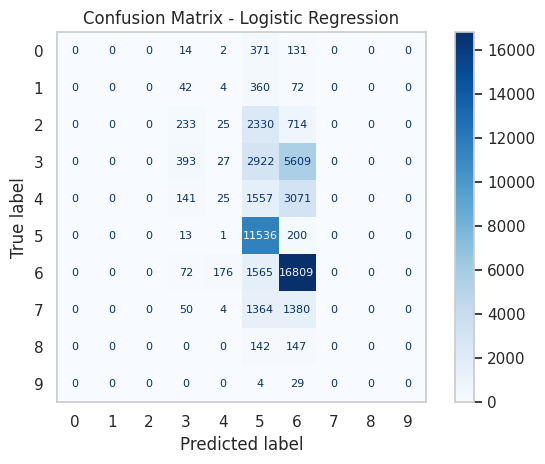

ROC curve not available for this multiclass model evaluation.

--- Training and Evaluating K-Nearest Neighbors ---
Training Time: 0.0738 seconds
Testing Time: 83.4868 seconds
Accuracy: 0.6651
Precision: 0.6769
Recall: 0.6651
F1-score: 0.6652

 Classification Report:

              precision    recall  f1-score   support

           0       0.15      0.09      0.11       518
           1       0.05      0.03      0.03       478
           2       0.31      0.43      0.36      3302
           3       0.38      0.46      0.42      8951
           4       0.37      0.30      0.33      4794
           5       0.99      0.97      0.98     11750
           6       0.79      0.79      0.79     18622
           7       0.75      0.36      0.49      2798
           8       0.38      0.12      0.18       289
           9       0.00      0.00      0.00        33

    accuracy                           0.67     51535
   macro avg       0.42      0.36      0.37     51535
weighted avg       0.68     

<Figure size 1000x800 with 0 Axes>

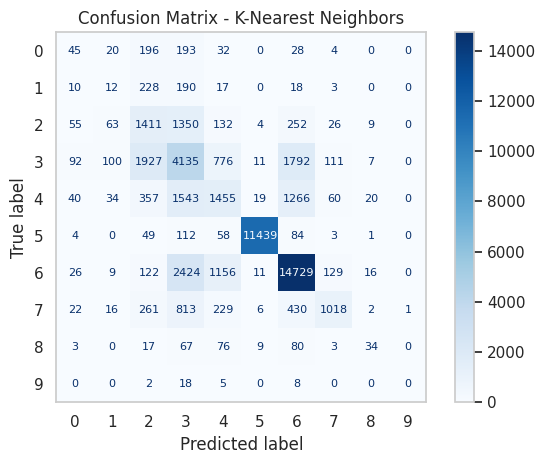

ROC curve not available for this multiclass model evaluation.

--- Training and Evaluating Gaussian Naive Bayes ---
Training Time: 0.2016 seconds
Testing Time: 0.1046 seconds
Accuracy: 0.4399
Precision: 0.5894
Recall: 0.4399
F1-score: 0.4077

 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       518
           1       0.00      0.00      0.00       478
           2       0.18      0.00      0.01      3302
           3       0.65      0.02      0.04      8951
           4       0.26      0.28      0.27      4794
           5       0.48      0.98      0.64     11750
           6       0.90      0.46      0.61     18622
           7       0.09      0.37      0.14      2798
           8       0.00      0.00      0.00       289
           9       0.00      0.03      0.01        33

    accuracy                           0.44     51535
   macro avg       0.26      0.21      0.17     51535
weighted avg       0.59     

<Figure size 1000x800 with 0 Axes>

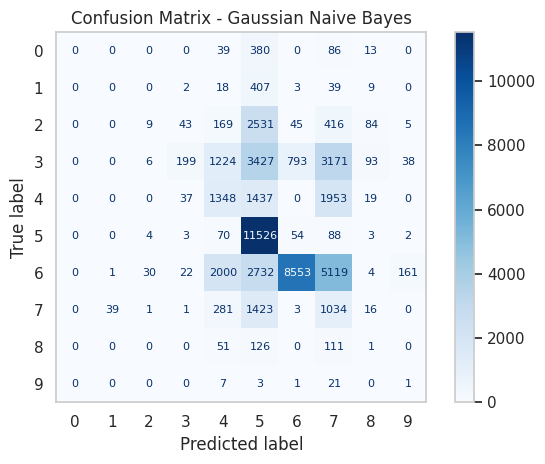

ROC curve not available for this multiclass model evaluation.

--- Training and Evaluating Neural Network ---
Training Time: 78.8948 seconds
Testing Time: 0.1441 seconds
Accuracy: 0.5819
Precision: 0.6677
Recall: 0.5819
F1-score: 0.5542

 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       518
           1       0.00      0.00      0.00       478
           2       0.39      0.01      0.02      3302
           3       0.31      0.93      0.47      8951
           4       0.41      0.15      0.22      4794
           5       0.88      0.97      0.93     11750
           6       0.95      0.51      0.66     18622
           7       0.09      0.01      0.01      2798
           8       0.00      0.00      0.00       289
           9       0.00      0.00      0.00        33

    accuracy                           0.58     51535
   macro avg       0.30      0.26      0.23     51535
weighted avg       0.67      0.58

<Figure size 1000x800 with 0 Axes>

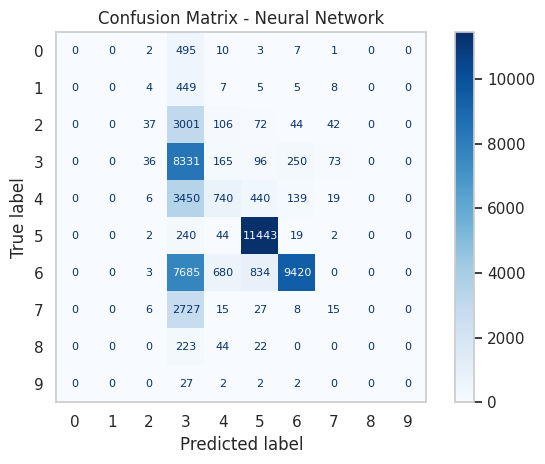

ROC curve not available for this multiclass model evaluation.

--- Model Performance Summary ---


,Training Time (s),Testing Time (s),Accuracy,Precision,Recall,F1-score
Logistic Regression,197.152894,0.018838,0.558126,0.414477,0.558126,0.429523
K-Nearest Neighbors,0.073807,83.486844,0.665140,0.676850,0.665140,0.665234
Gaussian Naive Bayes,0.201559,0.104638,0.439915,0.589403,0.439915,0.407707
Neural Network,78.894844,0.144130,0.581857,0.667691,0.581857,0.554166


In [15]:
import pandas as pd
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Dictionary to store models and their names
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=17),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=17)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training and Evaluating {name} ---")

    # Training time
    start_train_time = time.time()
    model.fit(X_train, y_train)
    end_train_time = time.time()
    train_time = end_train_time - start_train_time

    # Testing time and prediction
    start_test_time = time.time()
    y_pred = model.predict(X_test)
    end_test_time = time.time()
    test_time = end_test_time - start_test_time

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        "Training Time (s)": train_time,
        "Testing Time (s)": test_time,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    print(f"Training Time: {train_time:.4f} seconds")
    print(f"Testing Time: {test_time:.4f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Classification Report
    print("\n Classification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix: bigger, no grid, smaller annotation text
    plt.figure(figsize=(10, 8))  # increase size
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        cmap='Blues',
        values_format='.0f'  # cleaner integer labels
        # If you prefer no numbers at all, add: include_values=False
    )
    plt.grid(False)  # remove grid lines

    # shrink the numbers so they don't overlap
    for t in disp.text_.ravel():
        t.set_fontsize(8)   # adjust 7–10 as needed

    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()      # avoid clipping/overlap
    plt.show()

    # ROC Curve note
    print("ROC curve not available for this multiclass model evaluation.")

# Display a summary of results
print("\n--- Model Performance Summary ---")
results_df = pd.DataFrame(results).T
results_df


## **Deep learning Modle**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 64)          │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,346 (149.79 KB)

 Trainable params: 38,346 (149.79 KB)

 Non-trainable params: 0 (0.00 B)


--- Training the LSTM Model ---
Epoch 1/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.7316 - loss: 0.7978 - precision_2: 0.9141 - recall_2: 0.6039 - val_accuracy: 0.8059 - val_loss: 0.5123 - val_precision_2: 0.9281 - val_recall_2: 0.7334
Epoch 2/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.8120 - loss: 0.5188 - precision_2: 0.9315 - recall_2: 0.7206 - val_accuracy: 0.8306 - val_loss: 0.4737 - val_precision_2: 0.9392 - val_recall_2: 0.7354
Epoch 3/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.8258 - loss: 0.4866 - precision_2: 0.9275 - recall_2: 0.7371 - val_accuracy: 0.8377 - val_loss: 0.4524 - val_precision_2: 0.9433 - val_recall_2: 0.7427
Epoch 4/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.8317 - loss: 0.4680 - precision_2: 0.9293 - recall_2: 0.7466 - val_accuracy: 0.8393 - val_loss: 0.4377 - val_precision_2: 0.9405 - val_recall_2: 0.7705
Epoch 5/50
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.8337 - loss: 0

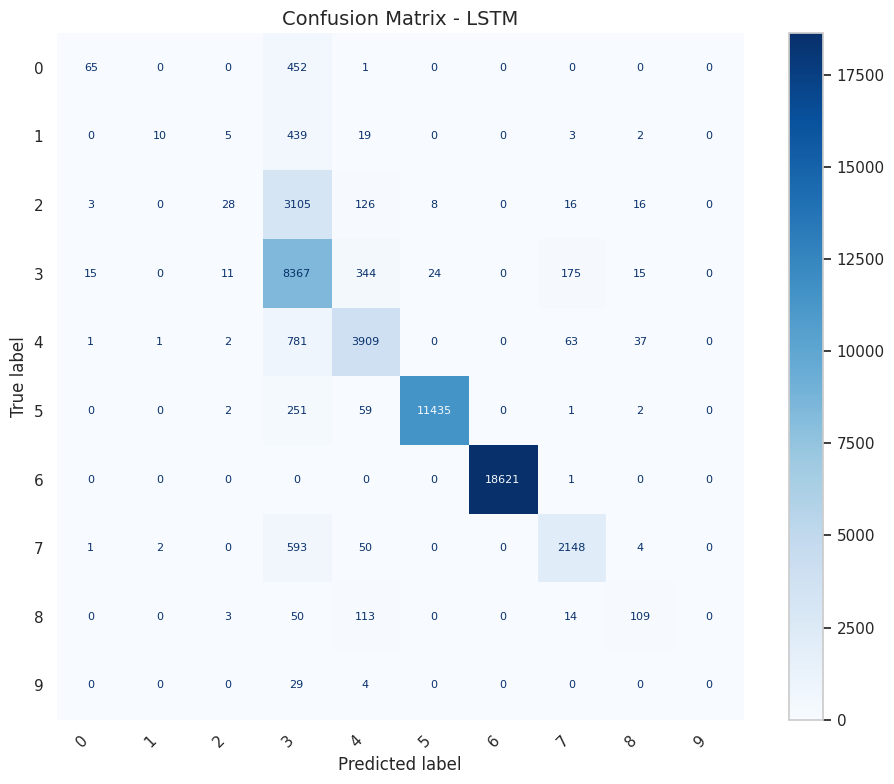


--- Plotting LSTM Training History ---


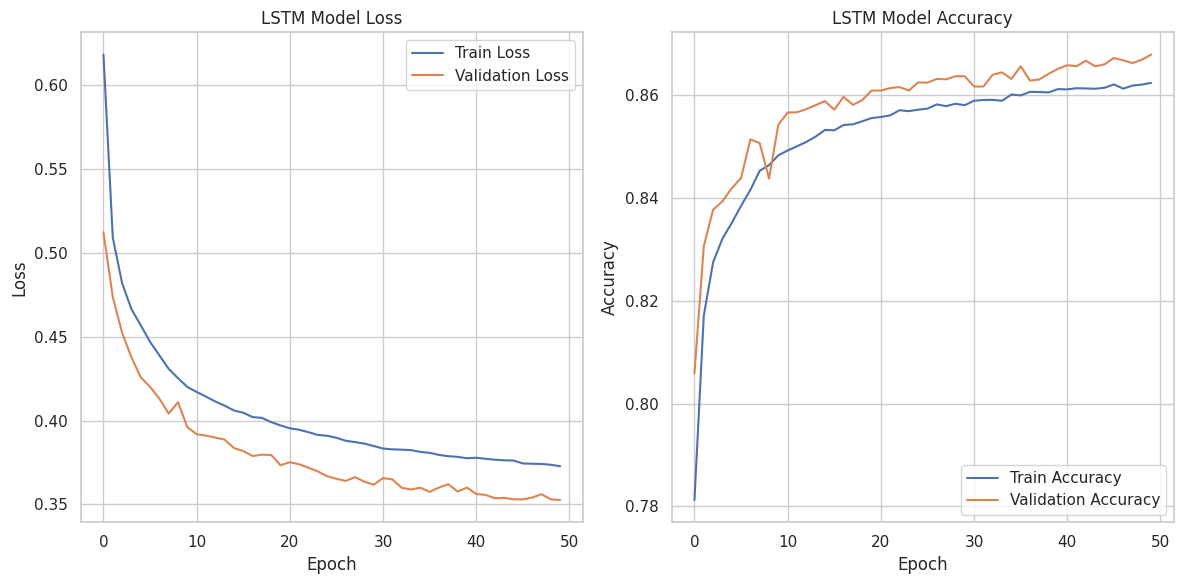


--- Plotting LSTM ROC Curve (One vs Rest) ---


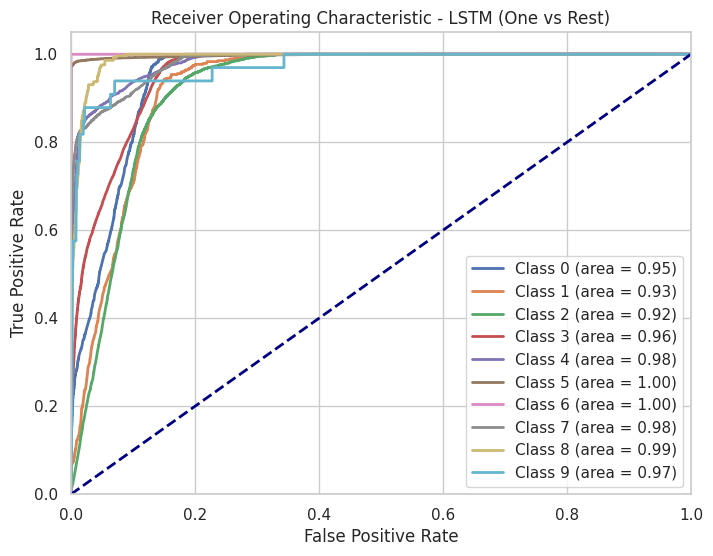


--- Updated Model Performance Summary ---
      Training Time (s)  Testing Time (s)  Accuracy  Precision    Recall  \
LSTM        1821.407875          5.192838  0.867216   0.951645  0.799282   

                       F1-score   ROC AUC  
LSTM  See Classification Report  See Plot  


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.metrics import Accuracy, Precision, Recall
from tensorflow.keras.utils import to_categorical # Import for one-hot encoding
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay # Import from sklearn for detailed report and confusion matrix
import tensorflow as tf


# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for LSTM (samples, timesteps, features)
# For this dataset, each sample is a single timestep
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# One-hot encode the target variable for multiclass classification
num_classes = len(y.unique()) # Get the number of unique classes
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)


# Build the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=32, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=num_classes, activation='softmax')) # Changed units to num_classes and activation to softmax

# Compile the model
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy', Precision(), Recall()]) # Changed loss to categorical_crossentropy and removed Keras F1Score


lstm_model.summary()

# Define callbacks for fine-tuning and saving the best model
# [removed early stopping]
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_lstm_model.h5', save_best_only=True, monitor='val_loss')

# Train the model
print("\n--- Training the LSTM Model ---")
start_lstm_train_time = time.time()
history = lstm_model.fit(
    X_train_reshaped, y_train_encoded, # Use one-hot encoded target
    epochs=50,
    validation_split=0.2, # Use part of training data for validation during training
    # callbacks=[model_checkpoint] # Added callbacks
)
end_lstm_train_time = time.time()
lstm_train_time = end_lstm_train_time - start_lstm_train_time
print(f"LSTM Training Time: {lstm_train_time:.4f} seconds")

# Evaluate the model on the test set
print("\n--- Evaluating the LSTM Model ---")
start_lstm_test_time = time.time()
loss, accuracy, precision, recall = lstm_model.evaluate(X_test_reshaped, y_test_encoded, verbose=0) # Evaluate with one-hot encoded target
end_lstm_test_time = time.time()
lstm_test_time = end_lstm_test_time - start_lstm_test_time
print(f"LSTM Testing Time: {lstm_test_time:.4f} seconds")

print(f"LSTM Test Loss: {loss:.4f}")
print(f"LSTM Test Accuracy: {accuracy:.4f}")
print(f"LSTM Test Precision: {precision:.4f}")
print(f"LSTM Test Recall: {recall:.4f}")


# Classification Report (needs thresholding for binary prediction)
y_pred_prob = lstm_model.predict(X_test_reshaped)
y_pred_lstm = np.argmax(y_pred_prob, axis=1) # Get the predicted class index

print("\n LSTM Classification Report:\n")
print(classification_report(y_test, y_pred_lstm, zero_division=0)) # Use original y_test for sklearn classification report

# Confusion Matrix for LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

fig, ax = plt.subplots(figsize=(10, 8))  # Increased figure size
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm)

# Plot without grid background
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.grid(False)  # Remove grid lines
for spine in ax.spines.values():
    spine.set_visible(False)  # Remove axis borders

# Adjust axis labels
disp.ax_.set_xlabel('Predicted label', fontsize=12)
disp.ax_.set_ylabel('True label', fontsize=12)

# Reduce cell text font size
for text in disp.ax_.texts:
    text.set_fontsize(8)

# Rotate x-axis labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Add title and adjust layout
plt.title("Confusion Matrix - LSTM", fontsize=14)
plt.tight_layout()
plt.show()

# Plot training history
print("\n--- Plotting LSTM Training History ---")
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# ROC Curve and AUC (Multiclass - One vs Rest)
# Note: ROC AUC for multiclass is typically done in a one-vs-rest or one-vs-one manner.
# Here's a simplified one-vs-rest example:
print("\n--- Plotting LSTM ROC Curve (One vs Rest) ---")
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, thresholds = roc_curve(y_test_encoded[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - LSTM (One vs Rest)')
plt.legend(loc="lower right")
plt.show()


# Add LSTM results to the summary
# Note: F1-score from evaluate is removed as it's not directly available for multiclass in Keras metrics.
# We'll rely on the classification_report for detailed F1-scores per class.
results['LSTM'] = {
    "Training Time (s)": lstm_train_time,
    "Testing Time (s)": lstm_test_time,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": "See Classification Report", # Indicate that F1-score is in the report
    "ROC AUC": "See Plot" # Indicate that ROC AUC is in the plot
}

# Display updated summary of results
print("\n--- Updated Model Performance Summary ---")
# Ensure 'GRU' key exists before accessing it, if the GRU cell hasn't been run yet
if 'GRU' in results:
    results_df_updated = pd.DataFrame(results).T
else:
    # Create a DataFrame with only the 'LSTM' results if GRU hasn't been added yet
    results_df_updated = pd.DataFrame([results['LSTM']], index=['LSTM'])

print(results_df_updated)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 1, 64)          │        19,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,130 (113.79 KB)

 Trainable params: 29,130 (113.79 KB)

 Non-trainable params: 0 (0.00 B)


--- Training the GRU Model ---
Epoch 1/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7115 - loss: 0.8626 - precision_3: 0.9020 - recall_3: 0.5726 - val_accuracy: 0.8028 - val_loss: 0.5291 - val_precision_3: 0.9170 - val_recall_3: 0.7369
Epoch 2/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8080 - loss: 0.5290 - precision_3: 0.9281 - recall_3: 0.7177 - val_accuracy: 0.8246 - val_loss: 0.4887 - val_precision_3: 0.9347 - val_recall_3: 0.7283
Epoch 3/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8206 - loss: 0.5015 - precision_3: 0.9297 - recall_3: 0.7268 - val_accuracy: 0.8324 - val_loss: 0.4741 - val_precision_3: 0.9268 - val_recall_3: 0.7439
Epoch 4/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8261 - loss: 0.4840 - precision_3: 0.9285 - recall_3: 0.7366 - val_accuracy: 0.8364 - val_loss: 0.4485 - val_precision_3: 0.9419 - val_recall_3: 0.7516
Epoch 5/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8316 - loss: 0.

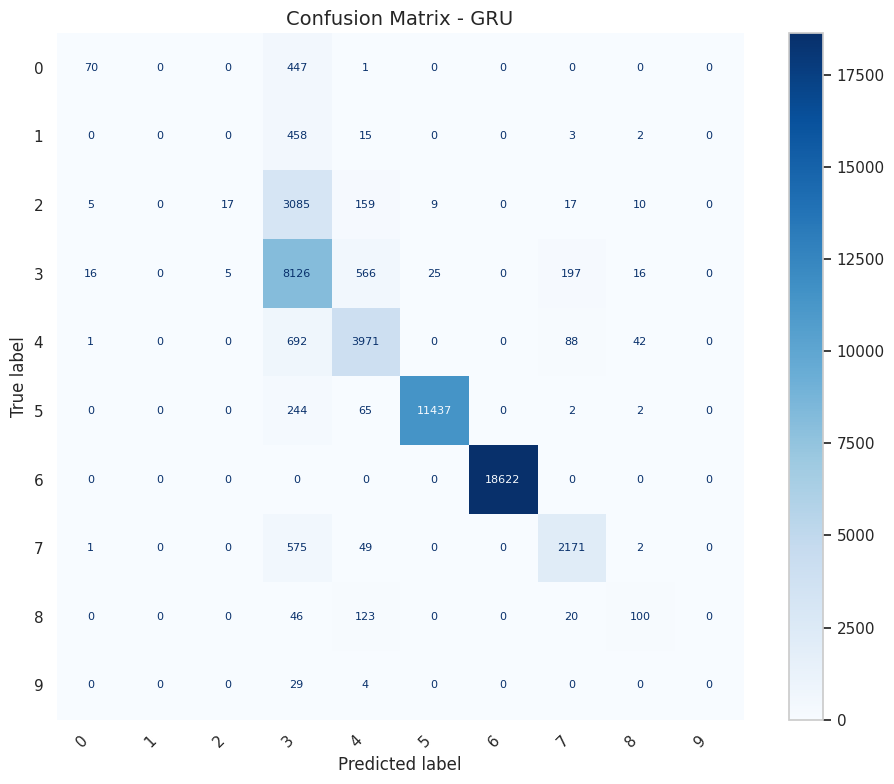


--- Plotting GRU Training History ---


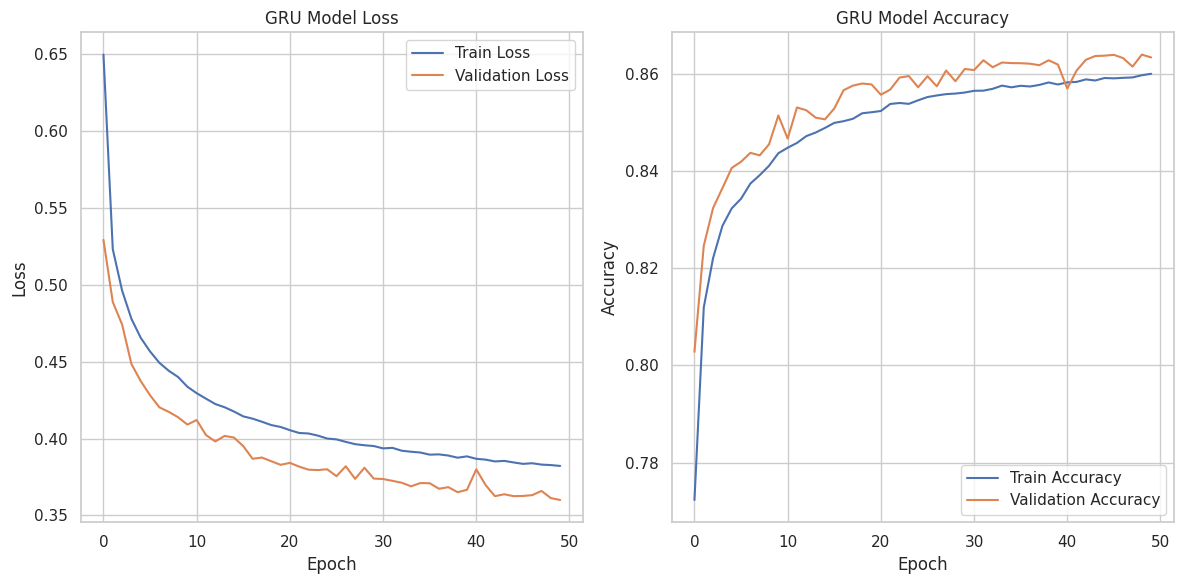


--- Plotting GRU ROC Curve (One vs Rest) ---


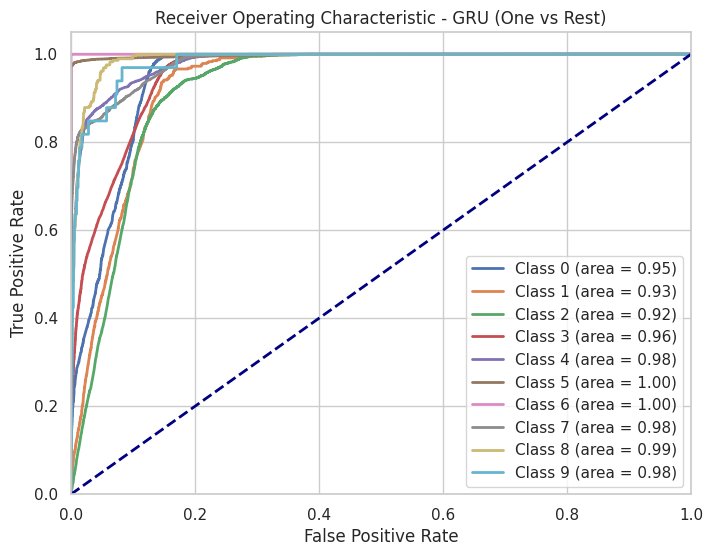


--- Updated Model Performance Summary ---
                     Training Time (s) Testing Time (s)  Accuracy Precision  \
Logistic Regression         197.152894         0.018838  0.558126  0.414477   
K-Nearest Neighbors           0.073807        83.486844   0.66514   0.67685   
Gaussian Naive Bayes          0.201559         0.104638  0.439915  0.589403   
Neural Network               78.894844          0.14413  0.581857  0.667691   
LSTM                       1821.407875         5.192838  0.867216  0.951645   
GRU                         872.440044         5.178915  0.863762  0.946601   

                        Recall                   F1-score   ROC AUC  
Logistic Regression   0.558126                   0.429523       NaN  
K-Nearest Neighbors    0.66514                   0.665234       NaN  
Gaussian Naive Bayes  0.439915                   0.407707       NaN  
Neural Network        0.581857                   0.554166       NaN  
LSTM                  0.799282  See Classification Re

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import GRU, Dense, Dropout # Added Dense and Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall # Removed F1Score
from tensorflow.keras.utils import to_categorical # Import for one-hot encoding
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc # Import from sklearn for detailed report, confusion matrix, and ROC AUC
import time # Import time

# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for GRU (samples, timesteps, features)
# For this dataset, each sample is a single timestep
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

# One-hot encode the target variable for multiclass classification
num_classes = len(y.unique()) # Get the number of unique classes
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)


# Build the GRU model
gru_model = Sequential()
gru_model.add(GRU(units=64, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(units=32, return_sequences=False))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(units=num_classes, activation='softmax')) # Changed units to num_classes and activation to softmax

# Compile the model
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy', Precision(), Recall()]) # Changed loss to categorical_crossentropy and removed Keras F1Score

gru_model.summary()

# Define callbacks for fine-tuning and saving the best model
# [removed early stopping]
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_gru_model.h5', save_best_only=True, monitor='val_loss')

# Train the model
print("\n--- Training the GRU Model ---")
start_gru_train_time = time.time()
history_gru = gru_model.fit(
    X_train_reshaped, y_train_encoded, # Use one-hot encoded target
    epochs=50,
    batch_size=64,
    validation_split=0.2, # Use part of training data for validation during training
    # callbacks=[model_checkpoint]
)
end_gru_train_time = time.time()
gru_train_time = end_gru_train_time - start_gru_train_time
print(f"GRU Training Time: {gru_train_time:.4f} seconds")

# Evaluate the model on the test set
print("\n--- Evaluating the GRU Model ---")
start_gru_test_time = time.time()
loss_gru, accuracy_gru, precision_gru, recall_gru = gru_model.evaluate(X_test_reshaped, y_test_encoded, verbose=0) # Evaluate with one-hot encoded target
end_gru_test_time = time.time()
gru_test_time = end_gru_test_time - start_gru_test_time
print(f"GRU Testing Time: {gru_test_time:.4f} seconds")

print(f"GRU Test Loss: {loss_gru:.4f}")
print(f"GRU Test Accuracy: {accuracy_gru:.4f}")
print(f"GRU Test Precision: {precision_gru:.4f}")
print(f"GRU Test Recall: {recall_gru:.4f}")


# Classification Report (needs thresholding for binary prediction)
y_pred_prob_gru = gru_model.predict(X_test_reshaped)
y_pred_gru = np.argmax(y_pred_prob_gru, axis=1) # Get the predicted class index

print("\n GRU Classification Report:\n")
print(classification_report(y_test, y_pred_gru, zero_division=0)) # Use original y_test for sklearn classification report

# Confusion Matrix for gru
cm_lstm = confusion_matrix(y_test, y_pred_gru)

fig, ax = plt.subplots(figsize=(10, 8))  # Increased figure size
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm)

# Plot without grid background
disp.plot(cmap='Blues', ax=ax, colorbar=True)
ax.grid(False)  # Remove grid lines
for spine in ax.spines.values():
    spine.set_visible(False)  # Remove axis borders

# Adjust axis labels
disp.ax_.set_xlabel('Predicted label', fontsize=12)
disp.ax_.set_ylabel('True label', fontsize=12)

# Reduce cell text font size
for text in disp.ax_.texts:
    text.set_fontsize(8)

# Rotate x-axis labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Add title and adjust layout
plt.title("Confusion Matrix - GRU", fontsize=14)
plt.tight_layout()
plt.show()

# Plot training history
print("\n--- Plotting GRU Training History ---")
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('GRU Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')
plt.title('GRU Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# ROC Curve and AUC (Multiclass - One vs Rest)
print("\n--- Plotting GRU ROC Curve (One vs Rest) ---")
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr_gru, tpr_gru, thresholds_gru = roc_curve(y_test_encoded[:, i], y_pred_prob_gru[:, i])
    roc_auc_gru = auc(fpr_gru, tpr_gru)
    plt.plot(fpr_gru, tpr_gru, lw=2, label=f'Class {i} (area = {roc_auc_gru:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - GRU (One vs Rest)')
plt.legend(loc="lower right")
plt.show()

# Add GRU results to the summary
# Ensure 'results' dictionary exists and contains previous results
if 'results' not in locals():
    results = {}

results['GRU'] = {
    "Training Time (s)": gru_train_time,
    "Testing Time (s)": gru_test_time,
    "Accuracy": accuracy_gru,
    "Precision": precision_gru,
    "Recall": recall_gru,
     "F1-score": "See Classification Report", # Indicate that F1-score is in the report
    "ROC AUC": "See Plot" # Indicate that ROC AUC is in the plot
}

# Display updated summary of results
print("\n--- Updated Model Performance Summary ---")
results_df_updated = pd.DataFrame(results).T
print(results_df_updated)